<a href="https://colab.research.google.com/github/DANUSHMATHI2002/Final-Project_Predicting-Chemical-Bioconcentration-in-Fish-Using-Machine-Learning/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **1. Installing and Importing Libraries**

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully!")

Libraries loaded successfully!


## **2. Load the Dataset**

In [6]:
df = pd.read_csv('/content/Fish_concentration.csv')

# Creating binary target (1 = Dangerous, 0 = Safe)
df['is_dangerous'] = df['Class'].apply(lambda x: 1 if x in [1, 2] else 0)

# Features list
feature_cols = ['nHM', 'piPC09', 'PCD', 'X2Av', 'MLOGP', 'ON1V', 'N-072', 'B02[C-N]', 'F04[C-O]']

print(f"Data loaded: {df.shape[0]} chemicals")
print(f"Safe: {(df['is_dangerous']==0).sum()}, Dangerous: {(df['is_dangerous']==1).sum()}")

Data loaded: 779 chemicals
Safe: 255, Dangerous: 524


# **3.Data Inspection(Missing Values, Shape, Info)**

In [9]:
# 1. Dataset shape (rows, columns)
print(f"\nDATASET SHAPE:")
print(f"   Rows: {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")

# 2. Column names
print(f"\nCOLUMN NAMES:")
print(f"   {list(df.columns)}")

# 3. Missing values check
print(f"\nMISSING VALUES:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   No missing values found.")
else:
    print(missing[missing > 0])

# 4. Data types
print(f"\nDATA TYPES:")
print(df.dtypes)

# 5. First 5 rows
print(f"\nFIRST 5 ROWS:")
print(df.head())

# 6. Last 5 rows
print(f"\nLAST 5 ROWS:")
print(df.tail())


DATASET SHAPE:
   Rows: 779
   Columns: 15

COLUMN NAMES:
   ['CAS', 'SMILES', 'Set', 'nHM', 'piPC09', 'PCD', 'X2Av', 'MLOGP', 'ON1V', 'N-072', 'B02[C-N]', 'F04[C-O]', 'Class', 'logBCF', 'is_dangerous']

MISSING VALUES:
   No missing values found.

DATA TYPES:
CAS              object
SMILES           object
Set              object
nHM               int64
piPC09          float64
PCD             float64
X2Av            float64
MLOGP           float64
ON1V            float64
N-072             int64
B02[C-N]          int64
F04[C-O]          int64
Class             int64
logBCF          float64
is_dangerous      int64
dtype: object

FIRST 5 ROWS:
        CAS                              SMILES    Set  nHM  piPC09   PCD  \
0  100-02-7             O=[N+](c1ccc(cc1)O)[O-]  Train    0     0.0  1.49   
1  100-17-4            O=[N+](c1ccc(cc1)OC)[O-]  Train    0     0.0  1.47   
2  100-18-5                c1cc(ccc1C(C)C)C(C)C  Train    0     0.0  1.20   
3  100-25-4  O=[N+]([O-])c1ccc(cc1)[N+](=

# **4. Statistical Summary**

In [10]:
print("\nDESCRIPTIVE STATISTICS:")
print(df.describe())

# For each feature, print mean, median, std
print("\nDETAILED STATISTICS PER FEATURE:")
feature_cols = ['nHM', 'piPC09', 'PCD', 'X2Av', 'MLOGP', 'ON1V', 'N-072', 'B02[C-N]', 'F04[C-O]']

stats_df = pd.DataFrame()
for feature in feature_cols:
    stats_df.loc[feature, 'Mean'] = df[feature].mean()
    stats_df.loc[feature, 'Median'] = df[feature].median()
    stats_df.loc[feature, 'Std Dev'] = df[feature].std()
    stats_df.loc[feature, 'Min'] = df[feature].min()
    stats_df.loc[feature, 'Max'] = df[feature].max()
    stats_df.loc[feature, 'Range'] = df[feature].max() - df[feature].min()

print(stats_df.round(2))


DESCRIPTIVE STATISTICS:
              nHM      piPC09         PCD        X2Av       MLOGP        ON1V  \
count  779.000000  779.000000  779.000000  779.000000  779.000000  779.000000   
mean     1.754814    3.467616    1.550822    0.236881    3.201746    1.510295   
std      1.985866    2.983778    0.958708    0.149319    1.595702    0.834753   
min      0.000000    0.000000    0.000000    0.090000   -1.960000    0.080000   
25%      0.000000    0.000000    1.210000    0.170000    2.190000    0.910000   
50%      1.000000    4.263000    1.400000    0.200000    3.130000    1.270000   
75%      3.000000    6.250000    2.285000    0.240000    4.235000    2.020000   
max     12.000000    9.316000    5.900000    2.230000    8.320000    7.190000   

            N-072    B02[C-N]    F04[C-O]       Class      logBCF  \
count  779.000000  779.000000  779.000000  779.000000  779.000000   
mean     0.186136    0.423620    3.585366    1.736842    2.062773   
std      0.501937    0.494449    4.430

# **5.Class Distribution**

In [12]:
# Original class distribution
class_counts = df['Class'].value_counts().sort_index()

print("\nORIGINAL CLASSES (1, 2, 3):")
for class_num in [1, 2, 3]:
    count = class_counts.get(class_num, 0)
    percent = count / len(df) * 100
    print(f"   Class {class_num}: {count} chemicals ({percent:.1f}%)")

# Creating binary target
df['is_dangerous'] = df['Class'].apply(lambda x: 1 if x in [1, 2] else 0)

print("\nBINARY TARGET (Dangerous vs Safe):")
safe_count = (df['is_dangerous'] == 0).sum()
danger_count = (df['is_dangerous'] == 1).sum()
print(f"   Safe (Class 3): {safe_count} chemicals ({safe_count/len(df)*100:.1f}%)")
print(f"   Dangerous (Class 1 and 2): {danger_count} chemicals ({danger_count/len(df)*100:.1f}%)")


ORIGINAL CLASSES (1, 2, 3):
   Class 1: 460 chemicals (59.1%)
   Class 2: 64 chemicals (8.2%)
   Class 3: 255 chemicals (32.7%)

BINARY TARGET (Dangerous vs Safe):
   Safe (Class 3): 255 chemicals (32.7%)
   Dangerous (Class 1 and 2): 524 chemicals (67.3%)


# **6.Check for Outliers**

In [13]:
outlier_summary = []
for feature in feature_cols:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    outlier_summary.append({
        'Feature': feature,
        'Outliers Count': len(outliers),
        'Outliers Percent': round((len(outliers) / len(df)) * 100, 2)
    })

# **Plot 1: Bar Chart (Class Distribution)**

Purpose: See if the data is imbalanced.


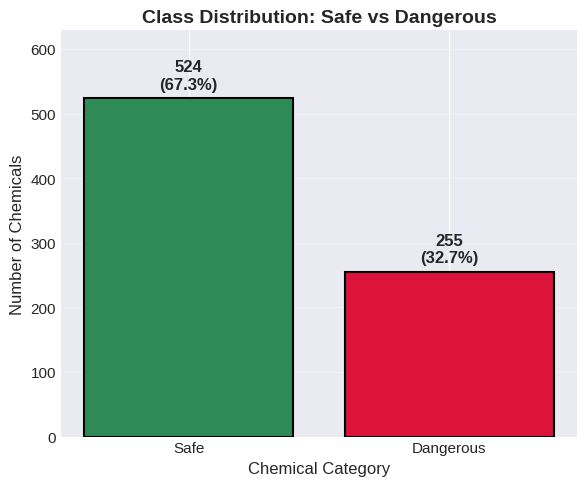

In [7]:
plt.figure(figsize=(6, 5))
counts = df['is_dangerous'].value_counts()
colors = ['#2E8B57', '#DC143C']  # SeaGreen for Safe, Crimson for Dangerous

bars = plt.bar(['Safe', 'Dangerous'], counts, color=colors, edgecolor='black', linewidth=1.5)

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{count}\n({count/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Class Distribution: Safe vs Dangerous', fontsize=14, fontweight='bold')
plt.xlabel('Chemical Category', fontsize=12)
plt.ylabel('Number of Chemicals', fontsize=12)
plt.ylim(0, counts.max() * 1.2)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# **Plot 2: Box Plots (Features by Class)**

Purpose: Find which features best separate Safe from Dangerous.

In [ ]:
# Prepare data
df_melt = df.melt(id_vars=['is_dangerous'], value_vars=feature_cols)
df_melt['Class'] = df_melt['is_dangerous'].map({0: 'Safe', 1: 'Dangerous'})


In [ ]:
# Plotting the data
plt.figure(figsize=(14, 7))
sns.boxplot(x='variable', y='value', hue='Class', data=df_melt,
            palette={'Safe': '#2E8B57', 'Dangerous': '#DC143C'})

plt.title('Feature Distributions: Safe vs Dangerous', fontsize=14, fontweight='bold')
plt.xlabel('Molecular Descriptor', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Chemical Type', loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Observe features where 'Safe' (green) and 'Dangerous' (red) boxes are clearly separated.")
print("MLOGP shows the most distinct separation, indicating it's the most important feature for classification.")

## **Plot 3: Correlation Heatmap**
Purpose: Find if any two features are too similar (redundant).

In [ ]:
corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0,
            fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Finding strong correlations
print("\nStrong correlations (|r| > 0.7):")
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {feature_cols[i]} ↔ {feature_cols[j]}: {r:.3f}")

#### **Simplified Correlation: `piPC09` and `PCD`**

`piPC09` and `PCD` are strongly related (0.74 correlation). This means they often change together, so they might be telling us similar things about the chemicals.

#### **Feature Redundancy: `piPC09` and `PCD`**

A strong positive correlation (0.74) exists between `piPC09` and `PCD`. This suggests that these two features might be redundant, providing similar information. For model simplification and to avoid multicollinearity, one might consider retaining only one of them.